In [2]:
import pandas as pd
import numpy as np
from ScanImageTiffReader import ScanImageTiffReader
import os
import matplotlib.pyplot as plt
import scipy.signal
import tifffile
from scipy.signal import butter, lfilter,find_peaks, gaussian, convolve
from ibllib.io.video import *
import scipy.ndimage
import cv2
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from matplotlib.animation import PillowWriter
from ScanImageTiffReader import ScanImageTiffReader
import json
from murphlib.caimage import *
from murphlib.tools import *
from murphlib.plotting import *
from murphlib.regression import *
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score
from scipy.stats import zscore
import scipy.io
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import seaborn as sns
plt.rcParams['animation.ffmpeg_path'] = r'D:\ffmpeg\bin\ffmpeg.exe'

In [3]:
tv = np.load(r'D:\Lab_Analysis\allenCCF\template_volume_10um.npy')

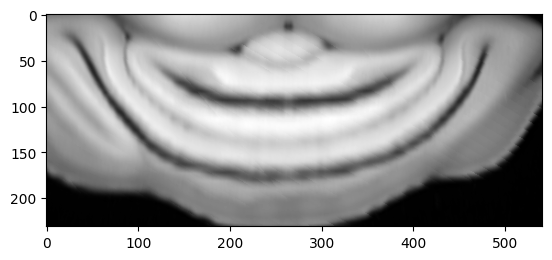

In [4]:
atlas_template = create_angled_slice(
        tv, 
        pitch_angle=5,  # 15 degrees nose down
        roll_angle=3,     # roll along ant-post axis, + rolls to the left
        slice_height=145
    )
atlas_template = atlas_template[1049:1280, 319:860]
plt.imshow(atlas_template,cmap='gray')

In [11]:
agg_data = {}
behav_train_path = r'Z:\TM_Lab\Edward\Data\iblrig_data\Subjects'
ca_img_path = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m'
mouse_ids = ['A_R2', 'A_R3', 'J_L2', 'O_R2', 'R_L2']
for mouse in mouse_ids:
    mouse_path = os.path.join(ca_img_path, mouse)
    subdir = [d for d in os.listdir(mouse_path)]
    dates = [s for s in subdir if s.isdigit()]

    mouse_data = {key: {} for key in dates + ['training']}
    for date in dates:
        session_path = os.path.join(mouse_path, date)
        bhv_path = os.path.join(session_path, 'behavior')
        subdir = [d for d in os.listdir(session_path)]
        if 'arm1' in subdir:
            arm1_img_path = os.path.join(session_path, 'arm1')
            arm1_stat = get_stat_with_coord(arm1_img_path)
            arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap.npy'), allow_pickle=True)
            predictors = arm1_ridge_model[0]['predictors']
            unique_predictors = arm1_ridge_model[0]['unique_predictors']
            arm1_stat = attach_reg_model_to_stat(arm1_stat, arm1_ridge_model)
            mouse_data[date]['arm1'] = np.array(arm1_stat, dtype=object)

        if 'arm2' in subdir:
            arm2_img_path = os.path.join(session_path, 'arm2')
            arm2_stat = get_stat_with_coord(arm2_img_path)
            arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap.npy'), allow_pickle=True)
            predictors = arm2_ridge_model[0]['predictors']
            unique_predictors = arm2_ridge_model[0]['unique_predictors']
            arm2_stat = attach_reg_model_to_stat(arm2_stat, arm2_ridge_model)
            mouse_data[date]['arm2'] = np.array(arm2_stat, dtype=object)
    os.makedirs(os.path.join(mouse_path, 'figures'), exist_ok=True)
    mouse_data['training']['accuracies_vis'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_vis.npy')) 
    mouse_data['training']['accuracies_aud'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_aud.npy'))
    mouse_data['training']['num_trials'] = np.load(os.path.join(behav_train_path,mouse, 'num_trials.npy'))  
    mouse_data['training']['training_dates'] = np.load(os.path.join(behav_train_path,mouse, 'training_dates.npy'))
    psth_time_start = -0.4
    psth_time_end = 1.2
    event_preds = unique_predictors[:10]
    for predi, pred in enumerate(event_preds):
        pred_idx = [i for i, name in enumerate(predictors) if pred in name]
        for dayi, date in enumerate(dates):
            session_path = os.path.join(mouse_path, date)
            
            if 'arm1' in mouse_data[date]:
                
                stat = mouse_data[date]['arm1']
                arm1_img_path = os.path.join(session_path, 'arm1')
                arm1_table_for_img = pd.read_csv(arm1_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
                frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
                arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    

                tf_arm1_table_for_img = transform_trial_table(arm1_table_for_img)
                psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm1_dff, psth_frame_idx, zscore=False)
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_psth = zscore(mean_psth, axis=1)
                    for i, neuron in enumerate(mouse_data[date]['arm1']):
                        beta = zscore(neuron['beta'][pred_idx])
                        psth = mean_psth[i,:]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth'] = psth
            if 'arm2' in mouse_data[date]:
                
                stat = mouse_data[date]['arm2']
                arm2_img_path = os.path.join(session_path, 'arm2')
                arm2_table_for_img = pd.read_csv(arm2_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
                frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
                arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    

                tf_arm2_table_for_img = transform_trial_table(arm2_table_for_img)
                psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm2_dff, psth_frame_idx, zscore=False)
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_psth = zscore(mean_psth, axis=1)
                    for i, neuron in enumerate(mouse_data[date]['arm2']):
                        beta = zscore(neuron['beta'][pred_idx])
                        psth = mean_psth[i,:]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth'] = psth
    agg_data[mouse] = mouse_data
    

In [15]:
def rolling_average(data, window_size):
    result = np.empty_like(data, dtype=float)
    
    for i in range(len(data)):
        start_idx = max(0, i - window_size + 1)
        result[i] = np.mean(data[start_idx:i+1])
    
    return result


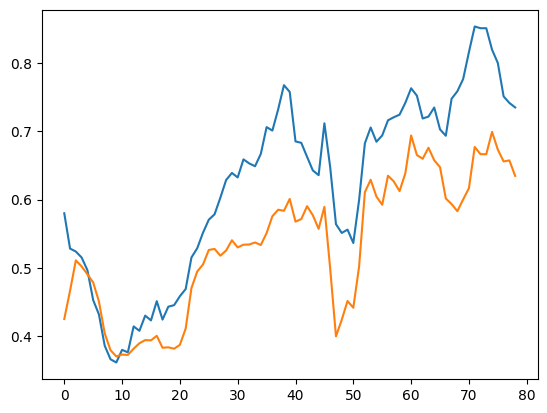

In [26]:
vis_perf = rolling_average(agg_data['A_R2']['training']['accuracies_vis'],5)
aud_perf = rolling_average(agg_data['A_R2']['training']['accuracies_aud'],5)
plt.plot(vis_perf)
plt.plot(aud_perf)

In [41]:
training_dates = agg_data['A_R2']['training']['training_dates']
ind = np.where(training_dates=='20240815')[0]
training_dates

array(['20240708', '20240709', '20240710', '20240711', '20240712',
       '20240714', '20240715', '20240716', '20240717', '20240718',
       '20240719', '20240722', '20240723', '20240724', '20240725',
       '20240729', '20240730', '20240731', '20240801', '20240802',
       '20240805', '20240806', '20240807', '20240808', '20240809',
       '20240812', '20240814', '20240816', '20240819', '20240820',
       '20240821', '20240822', '20240823', '20240826', '20240827',
       '20240828', '20240829', '20240830', '20240902', '20240903',
       '20240904', '20240905', '20240906', '20240909', '20240910',
       '20240916', '20240917', '20240918', '20240919', '20240920',
       '20240923', '20240924', '20240925', '20240926', '20240927',
       '20240930', '20241001', '20241002', '20241003', '20241004',
       '20241008', '20241010', '20241011', '20241014', '20241015',
       '20241017', '20241018', '20241021', '20241022', '20241024',
       '20241025', '20241028', '20241030', '20241031', '202411

In [93]:

event_preds = unique_predictors[:10]
for pred in event_preds:
    pred_idx = [i for i, name in enumerate(predictors) if pred in name]

    fig, axes = plt.subplots(2,2,figsize = (30,15))
    for idx in np.ndindex(axes.shape):
        row_idx, col_idx = idx
        ax = axes[idx]
        ax.imshow(atlas_template,cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0,0].set_title('Naive', fontsize = 30)
    axes[0,1].set_title('Vis expert', fontsize = 30)
    axes[1,0].set_title('Aud expert', fontsize = 30)
    axes[1,1].set_title('Double expert', fontsize = 30)
    fig.suptitle(pred, fontsize=30)
    for mouse in mouse_ids:
        mouse_data = agg_data[mouse]
        vis_perf = rolling_average(mouse_data['training']['accuracies_vis'],3)
        aud_perf = rolling_average(mouse_data['training']['accuracies_aud'],3)
        training_dates = mouse_data['training']['training_dates']
        img_dates = [i for i in mouse_data.keys() if i.isdigit()]
        
        for date in img_dates:
            training_day_num = np.where(training_dates==date)[0]
            if vis_perf[training_day_num] > 0.7 and aud_perf[training_day_num] > 0.7:
                status = 'db_expert'
                row = 1
                col = 1
            elif vis_perf[training_day_num] > 0.7:
                status = 'vis_expert'
                row = 0
                col= 1
            elif aud_perf[training_day_num] > 0.7:
                status = 'aud_expert'
                row = 1
                col = 0
            else:
                status = 'naive'
                row = 0
                col = 0
            
            if 'arm1' in mouse_data[date]:
                for i, neuron in enumerate(mouse_data[date]['arm1']):
                    #beta = zscore(neuron['beta'][pred_idx])
                    #midpoint = (len(beta)+1)//2
                    #resp_beta = np.mean(beta[midpoint:midpoint+int(0.4*15)])
                    resp_beta = np.mean(neuron['beta'][pred_idx])
                    #print(resp_beta)
                    axes[row, col].scatter(neuron['xcoord_atlas'], neuron['ycoord_atlas'], c=np.repeat(resp_beta,len(neuron['xcoord_atlas'])), cmap='coolwarm', vmin = -0.01, vmax = 0.01, s=0.001)
            if 'arm2' in mouse_data[date]:
                for i, neuron in enumerate(mouse_data[date]['arm2']):
                    #beta = zscore(neuron['beta'][pred_idx])
                    #midpoint = (len(beta)+1)//2
                    #resp_beta = np.mean(beta[midpoint:midpoint+int(0.4*15)])
                    resp_beta = np.mean(neuron['beta'][pred_idx])
                    #print(resp_beta)
                    axes[row, col].scatter(neuron['xcoord_atlas'], neuron['ycoord_atlas'], c=np.repeat(resp_beta,len(neuron['xcoord_atlas'])), cmap='coolwarm', vmin = -0.01, vmax = 0.01, s=0.001)
    fig.tight_layout()
    fig.savefig(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs', 'beta_'+ pred + '_topo.png'),
                dpi=300,               # High resolution for publication
                bbox_inches='tight',   # Prevent clipping
                )
    plt.close(fig)
    

C:\Users\dirk\AppData\Local\Temp\ipykernel_25324\1566074138.py:26: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if vis_perf[training_day_num] > 0.7 and aud_perf[training_day_num] > 0.7:
C:\Users\dirk\AppData\Local\Temp\ipykernel_25324\1566074138.py:30: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif vis_perf[training_day_num] > 0.7:
C:\Users\dirk\AppData\Local\Temp\ipykernel_25324\1566074138.py:34: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif aud_perf[training_day_num] > 0.7:


In [94]:
event_preds = unique_predictors[:10]
for pred in event_preds:
    pred_idx = [i for i, name in enumerate(predictors) if pred in name]
    unique_pred_idx = unique_predictors.index(pred)
    fig, axes = plt.subplots(2,2,figsize = (30,15))
    for idx in np.ndindex(axes.shape):
        row_idx, col_idx = idx
        ax = axes[idx]
        ax.imshow(atlas_template,cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0,0].set_title('Naive', fontsize = 30)
    axes[0,1].set_title('Vis expert', fontsize = 30)
    axes[1,0].set_title('Aud expert', fontsize = 30)
    axes[1,1].set_title('Double expert', fontsize = 30)
    fig.suptitle(pred, fontsize=30)
    for mouse in mouse_ids:
        mouse_data = agg_data[mouse]
        vis_perf = rolling_average(mouse_data['training']['accuracies_vis'],3)
        aud_perf = rolling_average(mouse_data['training']['accuracies_aud'],3)
        training_dates = mouse_data['training']['training_dates']
        img_dates = [i for i in mouse_data.keys() if i.isdigit()]
        
        for date in img_dates:
            training_day_num = np.where(training_dates==date)[0]
            if vis_perf[training_day_num] > 0.7 and aud_perf[training_day_num] > 0.7:
                status = 'db_expert'
                row = 1
                col = 1
            elif vis_perf[training_day_num] > 0.7:
                status = 'vis_expert'
                row = 0
                col= 1
            elif aud_perf[training_day_num] > 0.7:
                status = 'aud_expert'
                row = 1
                col = 0
            else:
                status = 'naive'
                row = 0
                col = 0
            ax = axes[row,col]
            if 'arm1' in mouse_data[date]:
                stat = mouse_data[date]['arm1']
                for i, neuron in enumerate(np.array(stat)):
                    if neuron['celltype'] == 'soma':
                        continue
                    bootstrap_p = holm_bonferroni_correction(neuron['bootstrap_p_value'])
                    r2 = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = bootstrap_p[unique_pred_idx]
                    r2 = 0 if p_value > 0.05 else r2
                    color = r2  # Gray for non-significant, R² for significant
                    #color = r2
                    ax.scatter(
                        neuron['xcoord_atlas'], 
                        neuron['ycoord_atlas'], 
                        c=color if color == 'gray' else np.repeat(r2, len(neuron['xcoord_atlas'])), 
                        cmap='coolwarm', 
                        vmin=-0.02, vmax=0.02, 
                        s=0.001
                    )

            # Plot arm2 neurons
            # Plot arm2 neurons
            if 'arm2' in mouse_data[date]:
                stat = mouse_data[date]['arm2']
                for i, neuron in enumerate(np.array(stat)):
                    if neuron['celltype'] == 'soma':
                        continue
                    bootstrap_p = holm_bonferroni_correction(neuron['bootstrap_p_value'])
                    r2 = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = bootstrap_p[unique_pred_idx]
                    r2 = 0 if p_value > 0.05 else r2
                    color = r2  # Gray for non-significant, R² for significant
                    #color = r2
                    ax.scatter(
                        neuron['xcoord_atlas'], 
                        neuron['ycoord_atlas'], 
                        c=color if color == 'gray' else np.repeat(r2, len(neuron['xcoord_atlas'])), 
                        cmap='coolwarm', 
                        vmin=-0.02, vmax=0.02, 
                        s=0.001
                    )
    fig.tight_layout()
    fig.savefig(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs', 'unique_r2_'+ pred + '_topo.png'),
                dpi=300,               # High resolution for publication
                bbox_inches='tight',   # Prevent clipping
                )
    plt.close(fig)

[]
[]


C:\Users\dirk\AppData\Local\Temp\ipykernel_25324\2901474383.py:28: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if vis_perf[training_day_num] > 0.7 and aud_perf[training_day_num] > 0.7:
C:\Users\dirk\AppData\Local\Temp\ipykernel_25324\2901474383.py:32: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif vis_perf[training_day_num] > 0.7:
C:\Users\dirk\AppData\Local\Temp\ipykernel_25324\2901474383.py:36: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif aud_perf[training_day_num] > 0.7:


[0.62760684]
[0.51767783]
[0.70555556]
[0.57257789]
[0.68460136]
[0.55777948]
[0.70926308]
[0.65743316]
[0.70166772]
[0.53203523]
[0.7659387]
[0.695]
[0.74052193]
[0.58485332]
[0.52269076]
[0.54147926]
[0.54755179]
[0.58949495]
[0.53750389]
[0.57244669]
[0.64314601]
[0.6150479]
[0.72380212]
[0.65154321]
[0.71589503]
[0.61814965]
[0.74803062]
[0.64840549]
[0.48146951]
[0.44130225]
[0.59785357]
[0.4330303]
[0.45221626]
[0.47083722]
[0.68518519]
[0.41]
[0.66037037]
[0.52111122]
[0.77813725]
[0.71700162]
[0.77479604]
[0.77164951]
[0.80264207]
[0.71903917]
[0.79993791]
[0.76736781]
[0.47903292]
[0.45280641]
[0.49157509]
[0.4753578]
[0.63051594]
[0.53611428]
[0.56254659]
[nan]
[0.6480129]
[0.66841358]
[0.76610225]
[0.81455999]
[0.81847061]
[0.83416783]
[0.82196697]
[0.81281863]
[0.802882]
[0.82062063]
[0.50620038]
[0.43333333]
[0.45207248]
[0.4463481]
[0.3673255]
[0.36712575]
[0.46735031]
[0.49144732]
[0.50825379]
[0.75837735]
[0.73497177]
[0.8137497]
[0.77473212]
[0.77897603]
[]
[]
[0.62760

In [43]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'leftchoice',
 'rightchoice',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos']

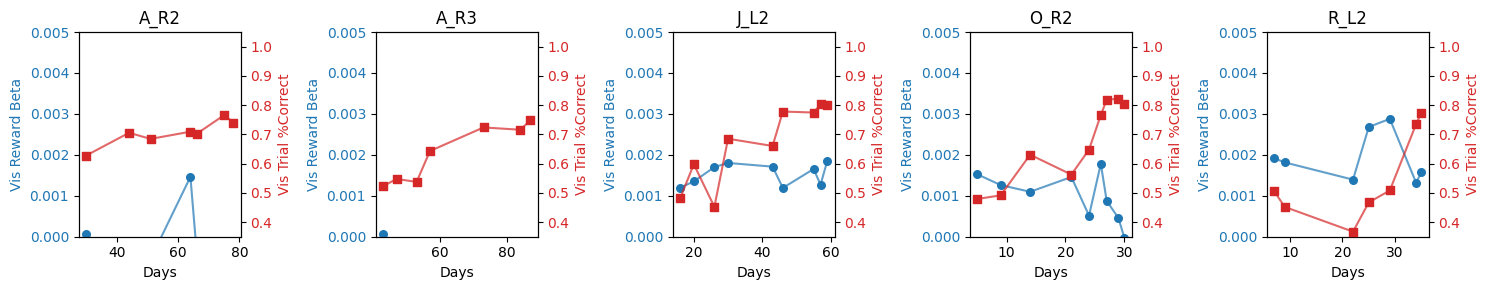

In [80]:
pred = 'vis_reward_times'
pred_idx = [i for i, name in enumerate(predictors) if pred in name]
fig, axes = plt.subplots(1, len(mouse_ids), figsize=(15, 3))
for mousei, mouse in enumerate(mouse_ids):

    mouse_data = agg_data[mouse]
    vis_perf = rolling_average(mouse_data['training']['accuracies_vis'], 3)
    aud_perf = rolling_average(mouse_data['training']['accuracies_aud'], 3)
    training_dates = mouse_data['training']['training_dates']
    img_dates = [i for i in mouse_data.keys() if i.isdigit()]

    beta_by_days = np.array([])
    vis_perf_by_days = np.array([])
    aud_perf_by_days = np.array([])
    training_day_count = np.array([])
    for date in img_dates:
        training_day_num = np.where(training_dates==date)[0]
        training_day_count = np.append(training_day_count, training_day_num)
        vis_perf_by_days = np.append(vis_perf_by_days, vis_perf[training_day_num])
        aud_perf_by_days = np.append(aud_perf_by_days, aud_perf[training_day_num])
        betas = np.array([])
        if 'arm1' in mouse_data[date]:
            for i, neuron in enumerate(mouse_data[date]['arm1']):
                resp_beta = np.mean(neuron['beta'][pred_idx])
                betas = np.append(betas, resp_beta)
        if 'arm2' in mouse_data[date]:
            for i, neuron in enumerate(mouse_data[date]['arm2']):
                resp_beta = np.mean(neuron['beta'][pred_idx])
                betas = np.append(betas, resp_beta)
        beta_by_days = np.append(beta_by_days, np.mean(betas))

    if mouse == 'A_R2':  # delete later.. 20240815 doesn't appear in training_data
        beta_by_days = beta_by_days[1:]
        
    # Plot z-scored data on primary axis
    ax1 = axes[mousei]
    color1 = 'tab:blue'
    ax1.set_xlabel('Days')
    ax1.set_ylabel('Vis Reward Beta', color=color1)
    
    # Add line
    line1 = ax1.plot(training_day_count, beta_by_days, color=color1, alpha=0.7)
    
    # Add scatter points
    scatter1 = ax1.scatter(training_day_count, beta_by_days, color=color1, s=30, zorder=3)
    
    ax1.tick_params(axis='y', labelcolor=color1)

    # Create secondary axis sharing the same x-axis
    ax2 = ax1.twinx()

    # Plot accuracy data on secondary axis
    color2 = 'tab:red'
    ax2.set_ylabel('Vis Trial %Correct', color=color2)
    
    # Add line
    line2 = ax2.plot(training_day_count, vis_perf_by_days, color=color2, alpha=0.7)
    
    # Add scatter points
    scatter2 = ax2.scatter(training_day_count, vis_perf_by_days, color=color2, s=30, zorder=3, marker='s')
    
    ax2.tick_params(axis='y', labelcolor=color2)

    # Set reasonable y-axis limits for both measures
    ax1.set_ylim(0, 0.005)  # typical range for z-scores
    ax2.set_ylim(0.35, 1.05)  # range for accuracy values

    # Add a title
    ax1.set_title(mouse)

plt.tight_layout()
plt.show()
    


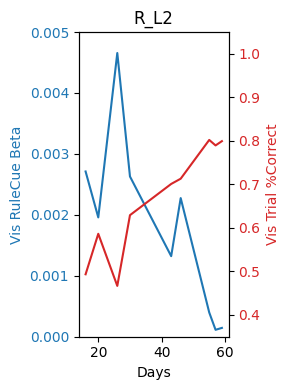

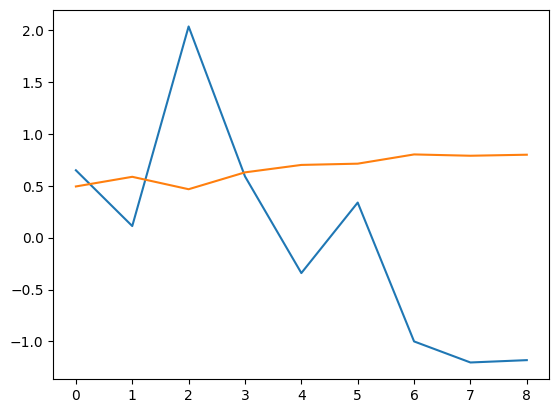

In [49]:
plt.plot(zscore(beta_by_days))
plt.plot(vis_perf_by_days)